In [6]:
import requests  # Used to send API requests
import pandas as pd  # Used to organize data into tables
import matplotlib.pyplot as plt  # Used to create diagrams

## Thesis:
### In 2024, there is a negative relationship between population growth rate and GDP per capita across countries.

# Population grouwth data

In [7]:
url_page_1 = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.GROW?format=json&per_page=500&page=1"

response_page_1 = requests.get(url_page_1)  # Send request for the first page
data_page_1 = response_page_1.json()  # Convert response into Python data

print(data_page_1[0])  # Show metadata

{'page': 1, 'pages': 36, 'per_page': 500, 'total': 17556, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [8]:
total_pages = data_page_1[0]['pages']  # Get the total number of pages
total_pages

36

In [9]:
all_records = []  # Create an empty list to store all records

for page in range(1, total_pages + 1):
    url = f"https://api.worldbank.org/v2/country/all/indicator/SP.POP.GROW?format=json&per_page=500&page={page}"
    response = requests.get(url)  # Send request for one page
    data = response.json()  # Convert response into Python data
    
    records = data[1]  # Get the actual records from this page
    all_records.extend(records)  # Add records to the full list
    
    print(f"Finished page {page}")  # Show progress

Finished page 1
Finished page 2
Finished page 3
Finished page 4
Finished page 5
Finished page 6
Finished page 7
Finished page 8
Finished page 9
Finished page 10
Finished page 11
Finished page 12
Finished page 13
Finished page 14
Finished page 15
Finished page 16
Finished page 17
Finished page 18
Finished page 19
Finished page 20
Finished page 21
Finished page 22
Finished page 23
Finished page 24
Finished page 25
Finished page 26
Finished page 27
Finished page 28
Finished page 29
Finished page 30
Finished page 31
Finished page 32
Finished page 33
Finished page 34
Finished page 35
Finished page 36


In [10]:
df_pop_raw = pd.DataFrame(all_records)  # Turn all records into a DataFrame
df_pop_raw.shape

(17556, 8)

In [11]:
df_pop = df_pop_raw[["country", "countryiso3code", "date", "value"]].copy()  # Keep only useful columns
df_pop.head()

,country,countryiso3code,date,value
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,2.472801
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,2.519167
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,2.592754
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,2.649439


In [12]:
country_names = []  # Create an empty list to store country names

for item in df_pop["country"]:
    country_names.append(item["value"])  # Get the name from each dictionary

df_pop["country_name"] = country_names  # Save the names as a new column

df_pop.head()  # Check the new column

,country,countryiso3code,date,value,country_name
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,Africa Eastern and Southern
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,2.472801,Africa Eastern and Southern
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,2.519167,Africa Eastern and Southern
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,2.592754,Africa Eastern and Southern
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,2.649439,Africa Eastern and Southern


In [13]:
df_pop["date"] = pd.to_numeric(df_pop["date"], errors="coerce")  # Convert year to numeric

print(df_pop["date"].dtype)  # Check the data type
df_pop["date"].head(10)

int64


0    2025
1    2024
2    2023
3    2022
4    2021
5    2020
6    2019
7    2018
8    2017
9    2016
Name: date, dtype: int64

In [14]:
df_pop_2024 = df_pop[df_pop["date"] == 2024].copy()  # Keep only rows for year 2024
df_pop_2024.shape

(266, 5)

In [15]:
df_pop_2024.isnull().sum()

country            0
countryiso3code    0
date               0
value              1
country_name       0
dtype: int64

In [16]:
df_pop_2024 = df_pop_2024.rename(columns={"value": "population_growth"})  # Rename the value column
df_pop_2024 = df_pop_2024.dropna(subset=["population_growth"])  # Remove missing values

df_pop_2024.shape

(265, 5)

In [17]:
df_pop_2024[["country_name", "countryiso3code", "date", "population_growth"]].head(20)

,country_name,countryiso3code,date,population_growth
1,Africa Eastern and Southern,AFE,2024,2.472801
67,Africa Western and Central,AFW,2024,2.398473
133,Arab World,ARB,2024,2.155917
199,Caribbean small states,CSS,2024,0.422919
265,Central Europe and the Baltics,CEB,2024,-0.121595
331,Early-demographic dividend,EAR,2024,1.151531
397,East Asia & Pacific,EAS,2024,0.162506
463,East Asia & Pacific (excluding high income),EAP,2024,0.168021
529,East Asia & Pacific (IDA & IBRD countries),TEA,2024,0.166308
595,Euro area,EMU,2024,0.399249


In [18]:
## download the country metadata and drop all the region data(keep only data from countries)

In [19]:
country_url = "https://api.worldbank.org/v2/country?format=json&per_page=400&page=1"

country_response = requests.get(country_url)
country_data = country_response.json() 

print(country_data[0])

{'page': 1, 'pages': 1, 'per_page': '400', 'total': 296}


In [20]:
country_records = country_data[1]  # Get the actual country metadata records

df_country_meta_raw = pd.DataFrame(country_records)  # Turn metadata into a DataFrame

df_country_meta_raw.head()

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,


In [21]:
df_country_meta = df_country_meta_raw[["id", "name", "region", "incomeLevel"]].copy()  # Keep useful columns

region_names = []  # Create an empty list to store region names

for item in df_country_meta["region"]:
    region_names.append(item["value"])  # Get the region name from each dictionary

df_country_meta["region_name"] = region_names  # Save region names as a new column

df_country_meta.head()

,id,name,region,incomeLevel,region_name
0,ABW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...",Latin America & Caribbean
1,AFE,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates
2,AFG,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","Middle East, North Africa, Afghanistan & Pakistan"
3,AFR,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates
4,AFW,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates


In [22]:
df_country_meta = df_country_meta.rename(columns={"id": "countryiso3code", "name": "meta_country_name"})  # Rename columns for merging

df_country_meta.head()

,countryiso3code,meta_country_name,region,incomeLevel,region_name
0,ABW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...",Latin America & Caribbean
1,AFE,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates
2,AFG,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","Middle East, North Africa, Afghanistan & Pakistan"
3,AFR,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates
4,AFW,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...",Aggregates


In [23]:
df_country_only = df_country_meta[df_country_meta["region_name"] != "Aggregates"].copy()  # Keep only real countries

df_country_only.shape

(217, 5)

In [24]:
df_pop_2024_country = pd.merge(
    df_pop_2024,
    df_country_only[["countryiso3code", "region_name"]],
    on="countryiso3code",
    how="inner"
)  # Merge population data with real-country metadata

df_pop_2024_country.shape

(217, 6)

In [25]:
df_pop_2024_country[["country_name", "countryiso3code", "date", "population_growth", "region_name"]].head(20)

,country_name,countryiso3code,date,population_growth,region_name
0,Afghanistan,AFG,2024,2.836573,"Middle East, North Africa, Afghanistan & Pakistan"
1,Albania,ALB,2024,-1.543144,Europe & Central Asia
2,Algeria,DZA,2024,1.398387,"Middle East, North Africa, Afghanistan & Pakistan"
3,American Samoa,ASM,2024,-1.603666,East Asia & Pacific
4,Andorra,AND,2024,1.329307,Europe & Central Asia
5,Angola,AGO,2024,3.044200,Sub-Saharan Africa
6,Antigua and Barbuda,ATG,2024,0.487472,Latin America & Caribbean
7,Argentina,ARG,2024,0.345830,Latin America & Caribbean
8,Armenia,ARM,2024,2.307615,Europe & Central Asia
9,Aruba,ABW,2024,0.590657,Latin America & Caribbean


# GDP per capita data

In [26]:
gdp_url_page_1 = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=500&page=1"

gdp_response_page_1 = requests.get(gdp_url_page_1)
gdp_data_page_1 = gdp_response_page_1.json()

print(gdp_data_page_1[0])

{'page': 1, 'pages': 36, 'per_page': 500, 'total': 17556, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [27]:
gdp_total_pages = gdp_data_page_1[0]["pages"]  # Get the total number of GDP pages
gdp_total_pages

36

In [28]:
gdp_all_records = []

for page in range(1, gdp_total_pages + 1):
    url = f"https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=500&page={page}"
    response = requests.get(url)  # Send request for one GDP page
    data = response.json() 
    
    records = data[1]  # Get the actual records from this page
    gdp_all_records.extend(records)  # Add records to the full list
    
    print(f"Finished GDP page {page}")

Finished GDP page 1
Finished GDP page 2
Finished GDP page 3
Finished GDP page 4
Finished GDP page 5
Finished GDP page 6
Finished GDP page 7
Finished GDP page 8
Finished GDP page 9
Finished GDP page 10
Finished GDP page 11
Finished GDP page 12
Finished GDP page 13
Finished GDP page 14
Finished GDP page 15
Finished GDP page 16
Finished GDP page 17
Finished GDP page 18
Finished GDP page 19
Finished GDP page 20
Finished GDP page 21
Finished GDP page 22
Finished GDP page 23
Finished GDP page 24
Finished GDP page 25
Finished GDP page 26
Finished GDP page 27
Finished GDP page 28
Finished GDP page 29
Finished GDP page 30
Finished GDP page 31
Finished GDP page 32
Finished GDP page 33
Finished GDP page 34
Finished GDP page 35
Finished GDP page 36


In [31]:
df_gdp_raw = pd.DataFrame(gdp_all_records)  # Turn into a DataFrame

df_gdp_raw.shape

(17556, 8)

In [33]:
df_gdp = df_gdp_raw[["country", "countryiso3code", "date", "value"]].copy() 

df_gdp.head()

,country,countryiso3code,date,value
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1571.449189
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1679.327622
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1562.416175


In [35]:
gdp_country_names = []

for item in df_gdp["country"]:
    gdp_country_names.append(item["value"])

df_gdp["country_name"] = gdp_country_names 

df_gdp.head()

,country,countryiso3code,date,value,country_name
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,Africa Eastern and Southern
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356,Africa Eastern and Southern
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1571.449189,Africa Eastern and Southern
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1679.327622,Africa Eastern and Southern
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1562.416175,Africa Eastern and Southern


In [41]:
df_gdp["date"] = pd.to_numeric(df_gdp["date"], errors="coerce")
df_gdp_2024 = df_gdp[df_gdp["date"] == 2024].copy() ## take only 2024

df_gdp_2024.shape

(266, 5)

In [44]:
df_gdp_2024 = df_gdp_2024.rename(columns={"value": "gdp_per_capita"})  # Rename value column
df_gdp_2024 = df_gdp_2024.dropna(subset=["gdp_per_capita"])  # Remove missing values

df_gdp_2024.shape

(240, 5)

In [47]:
df_gdp_2024.head()

,country,countryiso3code,date,gdp_per_capita,country_name
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356,Africa Eastern and Southern
67,"{'id': 'ZI', 'value': 'Africa Western and Cent...",AFW,2024,1411.337029,Africa Western and Central
133,"{'id': '1A', 'value': 'Arab World'}",ARB,2024,7583.811701,Arab World
199,"{'id': 'S3', 'value': 'Caribbean small states'}",CSS,2024,19903.811231,Caribbean small states
265,"{'id': 'B8', 'value': 'Central Europe and the ...",CEB,2024,24604.806860,Central Europe and the Baltics


In [46]:
df_gdp_2024_country = pd.merge(
    df_gdp_2024,
    df_country_only[["countryiso3code", "region_name"]],
    on="countryiso3code",
    how="inner"
)  # Keep only real countries by merging with country metadata

df_gdp_2024_country.shape

(192, 6)

In [49]:
df_gdp_2024_country[["country_name", "countryiso3code", "date", "gdp_per_capita", "region_name"]].head(20)

,country_name,countryiso3code,date,gdp_per_capita,region_name
0,Albania,ALB,2024,11377.775743,Europe & Central Asia
1,Algeria,DZA,2024,5752.990767,"Middle East, North Africa, Afghanistan & Pakistan"
2,Andorra,AND,2024,49303.649167,Europe & Central Asia
3,Angola,AGO,2024,2665.874448,Sub-Saharan Africa
4,Antigua and Barbuda,ATG,2024,23542.452695,Latin America & Caribbean
5,Argentina,ARG,2024,13969.783660,Latin America & Caribbean
6,Armenia,ARM,2024,8556.214070,Europe & Central Asia
7,Aruba,ABW,2024,39498.594129,Latin America & Caribbean
8,Australia,AUS,2024,64603.985631,East Asia & Pacific
9,Austria,AUT,2024,58268.878765,Europe & Central Asia


In [50]:
## merging the two datasets

In [52]:
df_final = pd.merge(
    df_pop_2024_country[["country_name", "countryiso3code", "date", "population_growth", "region_name"]],
    df_gdp_2024_country[["countryiso3code", "gdp_per_capita"]],
    on="countryiso3code",
    how="inner"
)  # Merge population growth data with GDP per capita data

df_final.shape

(192, 6)

In [53]:
df_final.head()

,country_name,countryiso3code,date,population_growth,region_name,gdp_per_capita
0,Albania,ALB,2024,-1.543144,Europe & Central Asia,11377.775743
1,Algeria,DZA,2024,1.398387,"Middle East, North Africa, Afghanistan & Pakistan",5752.990767
2,Andorra,AND,2024,1.329307,Europe & Central Asia,49303.649167
3,Angola,AGO,2024,3.044200,Sub-Saharan Africa,2665.874448
4,Antigua and Barbuda,ATG,2024,0.487472,Latin America & Caribbean,23542.452695


In [54]:
df_final.isnull().sum()

country_name         0
countryiso3code      0
date                 0
population_growth    0
region_name          0
gdp_per_capita       0
dtype: int64

In [55]:
df_final.duplicated().sum()

np.int64(0)

In [56]:
df_final["countryiso3code"].duplicated().sum()

np.int64(0)

In [59]:
len(df_final)  # Count total rows

192

In [60]:
df_final["countryiso3code"].nunique()  # Count unique country codes

192

In [61]:
# The final dataset has no missing values, no duplicate rows,
# and no duplicate country codes.

In [68]:
## corelation
## answer: In 2024, there is a negative relationship between population growth rate and GDP per capita across countries.
correlation = df_final["population_growth"].corr(df_final["gdp_per_capita"])  # Calculate correlation between the two variables
correlation

np.float64(-0.12098212344415442)

In [69]:
df_final[["population_growth", "gdp_per_capita"]].describe()  # summary statistics

,population_growth,gdp_per_capita
count,192.000000,192.000000
mean,1.117482,21312.217011
std,1.357874,32265.154161
min,-5.391262,219.424831
25%,0.334448,2687.521968
50%,0.992318,8074.625991
75%,1.960799,29315.186319
max,7.322652,288001.433369


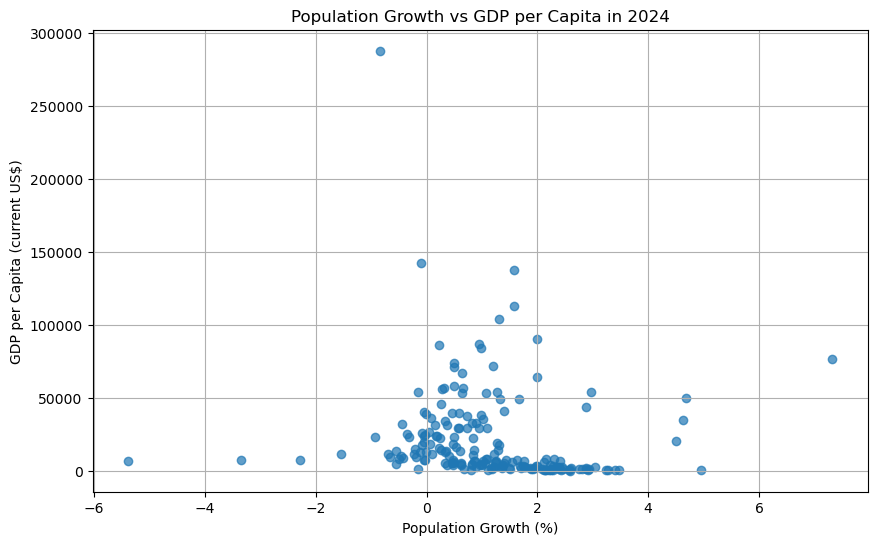

In [71]:
plt.figure(figsize=(10, 6))
plt.scatter(df_final["population_growth"], df_final["gdp_per_capita"], alpha=0.7)

plt.xlabel("Population Growth (%)")
plt.ylabel("GDP per Capita (current US$)")
plt.title("Population Growth vs GDP per Capita in 2024")
plt.grid(True)

plt.savefig("../output/scatter_plot.png", bbox_inches="tight") 
plt.show()

## groupth group

In [73]:
q1 = df_final["population_growth"].quantile(0.25)  # Get the 25th percentile
q2 = df_final["population_growth"].quantile(0.50)  # Get the median
q3 = df_final["population_growth"].quantile(0.75)  # Get the 75th percentile

In [74]:
## group by 25%, 50%, 75% percentages and get the four groups
def assign_quartile(value):
    if value <= q1:
        return "Q1 (lowest 25%)"
    elif value <= q2:
        return "Q2 (25%-50%)" 
    elif value <= q3:
        return "Q3 (50%-75%)"
    else:
        return "Q4 (highest 25%)"

In [75]:
df_final["growth_quartile"] = df_final["population_growth"].apply(assign_quartile)  # Assign each country to a quartile group

df_final[["country_name", "population_growth", "growth_quartile"]].head(20)

,country_name,population_growth,growth_quartile
0,Albania,-1.543144,Q1 (lowest 25%)
1,Algeria,1.398387,Q3 (50%-75%)
2,Andorra,1.329307,Q3 (50%-75%)
3,Angola,3.044200,Q4 (highest 25%)
4,Antigua and Barbuda,0.487472,Q2 (25%-50%)
5,Argentina,0.345830,Q2 (25%-50%)
6,Armenia,2.307615,Q4 (highest 25%)
7,Aruba,0.590657,Q2 (25%-50%)
8,Australia,1.993837,Q4 (highest 25%)
9,Austria,0.504880,Q2 (25%-50%)


In [76]:
df_final["growth_quartile"].value_counts()  # Count how many countries are in each quartile

growth_quartile
Q1 (lowest 25%)     48
Q3 (50%-75%)        48
Q4 (highest 25%)    48
Q2 (25%-50%)        48
Name: count, dtype: int64

In [77]:
quartile_gdp = df_final.groupby("growth_quartile")["gdp_per_capita"].mean().reset_index()  # Calculate average GDP per capita for each quartile

quartile_gdp

,growth_quartile,gdp_per_capita
0,Q1 (lowest 25%),30541.753369
1,Q2 (25%-50%),24372.502478
2,Q3 (50%-75%),19499.166367
3,Q4 (highest 25%),10835.445828


In [78]:
quartile_order = ["Q1 (lowest 25%)", "Q2 (25%-50%)", "Q3 (50%-75%)", "Q4 (highest 25%)"]  # Set the order

quartile_gdp

,growth_quartile,gdp_per_capita
0,Q1 (lowest 25%),30541.753369
1,Q2 (25%-50%),24372.502478
2,Q3 (50%-75%),19499.166367
3,Q4 (highest 25%),10835.445828


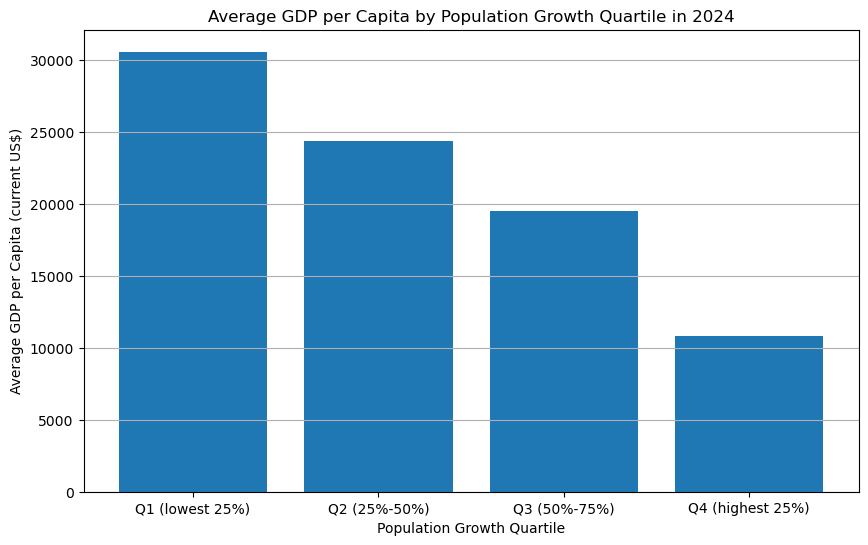

In [81]:
plt.figure(figsize=(10, 6)) 
plt.bar(quartile_gdp["growth_quartile"], quartile_gdp["gdp_per_capita"])  # bar chart

plt.xlabel("Population Growth Quartile")
plt.ylabel("Average GDP per Capita (current US$)")
plt.title("Average GDP per Capita by Population Growth Quartile in 2024")
plt.grid(axis="y") 

plt.savefig("../output/quartile_bar_chart.png", bbox_inches="tight")
plt.show()

## Conclusion:
- The results suggest a weak negative relationship between population growth and GDP per capita across countries in 2024.
- The correlation coefficient is about -0.121, which shows a negative and weak relationship.
- The quartile analysis also shows that countries in the lowest population growth quartile had the highest average GDP per capita, while countries in the highest population growth quartile had the lowest average GDP per capita.